# Customer Segmentation Analysis — FMCG Loyalty Card Data

**Goal:** Segment 2,000 supermarket loyalty-card customers into meaningful groups, using three clustering methods that make progressively better use of the dataset's mixed numeric/categorical structure — and empirically justify which one actually performs best, rather than assuming it from theory alone.

**Dataset:** 2,000 anonymized FMCG customers, 7 features (demographic + socioeconomic), no missing values. Full variable dictionary in `data/segmentation_data_legend.xlsx`.

**Notebook structure:**
1. Data loading & quality check
2. Exploratory Data Analysis
3. Hypothesis testing (with assumption checks)
4. K-Means: choosing k (elbow + silhouette), fitting
5. K-Prototypes: choosing k (elbow + silhouette), fitting
6. K-Means vs. K-Prototypes — empirical comparison (not just theory)
7. Hierarchical clustering (Gower distance, linkage comparison, dendrogram)
8. Three-way comparison of all methods
9. Cluster profiling — business personas
10. PCA — visualization & multicollinearity check
11. Final report & recommendations


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram

from src.data_loader import load_raw, load_labeled, basic_quality_report, CATEGORICAL_COLS, NUMERIC_COLS
from src.stats_tests import chi_square_test, two_group_test, one_way_anova, pearson_correlation
from src.clustering import (
    prepare_kmeans_input, prepare_kprototypes_input,
    elbow_and_silhouette_kmeans, cost_kprototypes, elbow_and_silhouette_kprototypes,
    run_kmeans, run_kprototypes, compare_clusterings,
    compute_gower_matrix, gower_silhouette, categorical_purity, numeric_separation, empirical_comparison,
    hierarchical_linkage, cophenetic_correlation, cut_tree, elbow_and_silhouette_hierarchical,
    pca_2d, profile_clusters
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 1. Data Loading & Quality Check

Two dataframe versions are kept throughout: `df_raw` (integer-coded categoricals, needed by all clustering algorithms) and `df_labeled` (human-readable categories, needed for EDA and profiling).

In [2]:
df_raw = load_raw("../data/segmentation_data.csv")
df_labeled = load_labeled("../data/segmentation_data.csv")

report = basic_quality_report(df_raw)
print(f"Rows: {report['n_rows']}, Columns: {report['n_cols']}")
print(f"Duplicate IDs: {report['duplicate_ids']}")
print(f"Missing values per column: {report['missing_values']}")

df_labeled.head()


Rows: 2000, Columns: 8
Duplicate IDs: 0
Missing values per column: {'ID': 0, 'Sex': 0, 'Marital status': 0, 'Age': 0, 'Education': 0, 'Income': 0, 'Occupation': 0, 'Settlement size': 0}


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,male,single,67,university,124670,skilled employee,big city
1,100000002,female,non-single,22,high school,150773,skilled employee,big city
2,100000003,male,single,49,high school,89210,unemployed/unskilled,small city
3,100000004,male,single,45,high school,171565,skilled employee,mid-sized city
4,100000005,male,single,53,high school,149031,skilled employee,mid-sized city


## 2. Exploratory Data Analysis

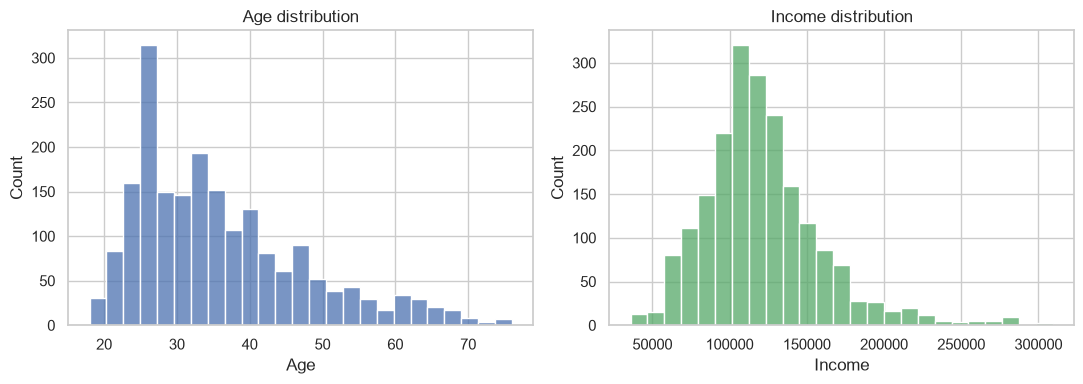

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_raw["Age"], bins=25, ax=axes[0], color="#4C72B0")
axes[0].set_title("Age distribution")
sns.histplot(df_raw["Income"], bins=25, ax=axes[1], color="#55A868")
axes[1].set_title("Income distribution")
plt.tight_layout()
plt.savefig("../outputs/figures/01_numeric_distributions.png", bbox_inches="tight")
plt.show()


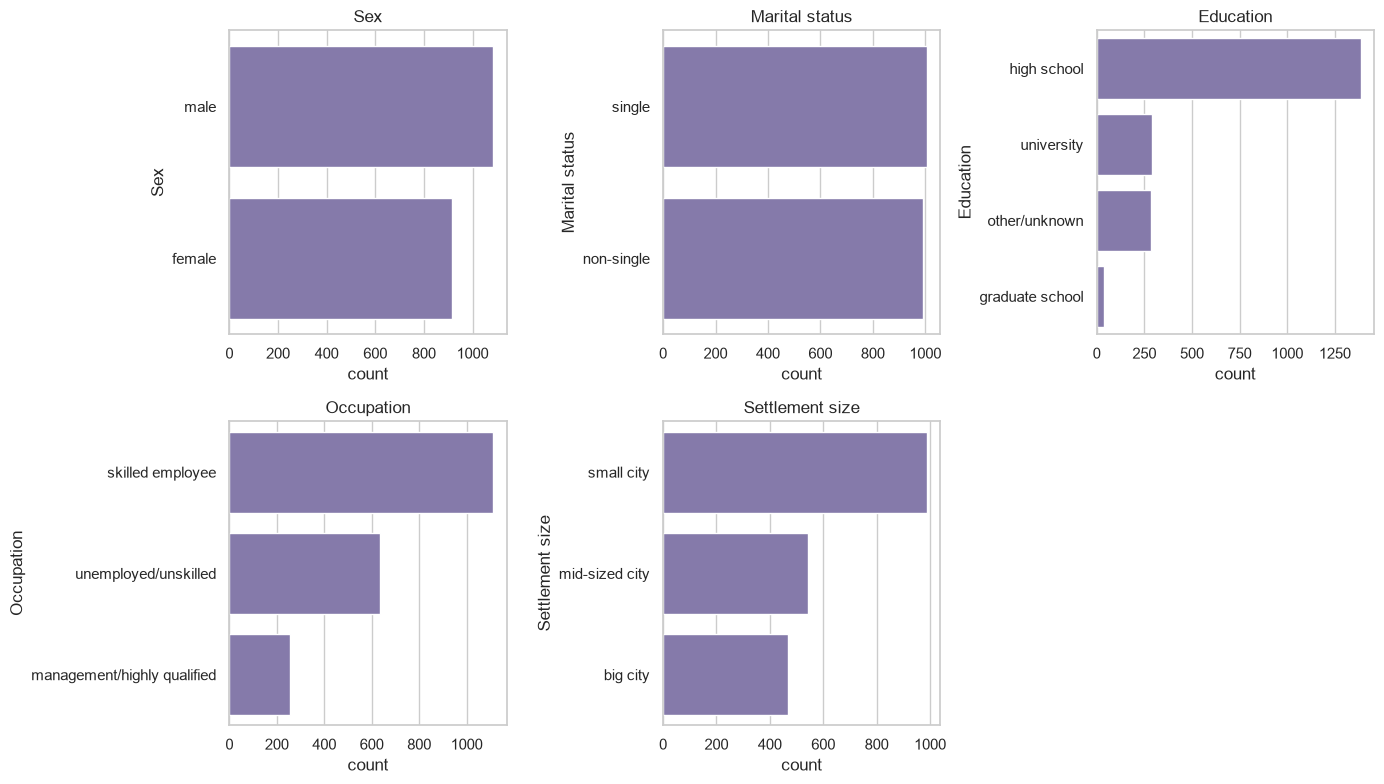

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(CATEGORICAL_COLS):
    order = df_labeled[col].value_counts().index
    sns.countplot(data=df_labeled, y=col, order=order, ax=axes[i], color="#8172B2")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/02_categorical_distributions.png", bbox_inches="tight")
plt.show()


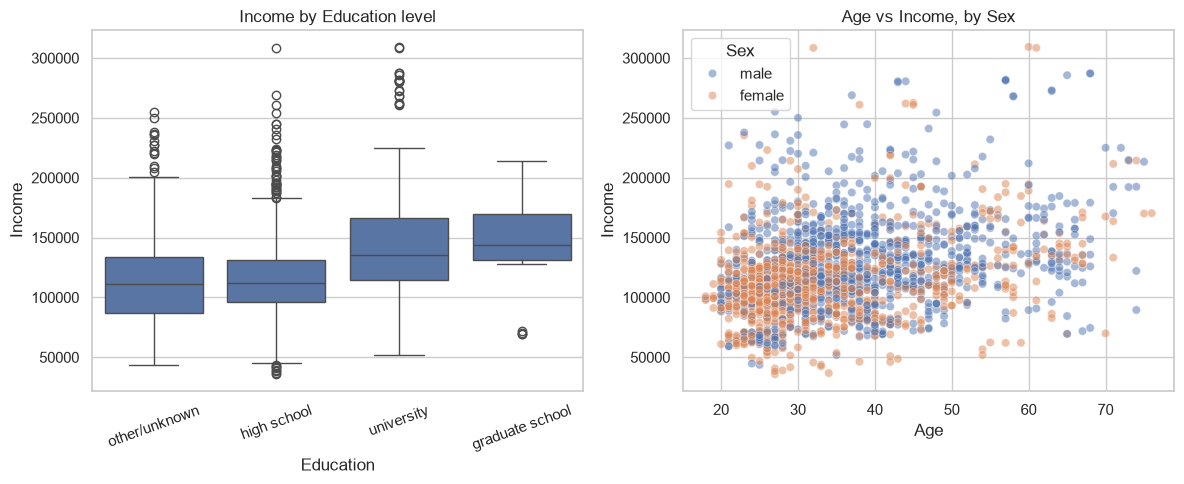

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_labeled, x="Education", y="Income", ax=axes[0],
            order=["other/unknown", "high school", "university", "graduate school"])
axes[0].set_title("Income by Education level")
axes[0].tick_params(axis='x', rotation=20)
sns.scatterplot(data=df_labeled, x="Age", y="Income", hue="Sex", alpha=0.5, ax=axes[1])
axes[1].set_title("Age vs Income, by Sex")
plt.tight_layout()
plt.savefig("../outputs/figures/03_income_relationships.png", bbox_inches="tight")
plt.show()


**Observations:** Income rises visibly with education level. Age and Income show a mild positive trend, worth testing formally. Category counts are reasonably balanced.

## 3. Hypothesis Testing

Each test below checks its own assumptions (normality via Shapiro-Wilk, equal variance via Levene's test) and automatically falls back to the appropriate non-parametric alternative when an assumption is violated, rather than blindly applying a parametric test.

In [6]:
results = []
results.append(chi_square_test(df_labeled, "Marital status", "Settlement size"))
results.append(chi_square_test(df_labeled, "Sex", "Occupation"))
results.append(chi_square_test(df_labeled, "Education", "Settlement size"))
results.append(two_group_test(df_raw, "Income", "Sex"))
results.append(two_group_test(df_raw, "Income", "Marital status"))
results.append(one_way_anova(df_raw, "Income", "Education"))
results.append(one_way_anova(df_raw, "Income", "Occupation"))
results.append(one_way_anova(df_raw, "Age", "Settlement size"))
results.append(pearson_correlation(df_raw, "Age", "Income"))

summary = pd.DataFrame([
    {
        "Test": r["test"], "Variables": r["variables"],
        "Statistic": round(r.get("statistic", r.get("r", np.nan)), 3),
        "p-value": f"{r['p_value']:.2e}", "Significant (a=0.05)": r["significant"],
    } for r in results
])
summary


,Test,Variables,Statistic,p-value,Significant (a=0.05)
0,Chi-square test of independence,Marital status vs Settlement size,20.195,4.12e-05,True
1,Chi-square test of independence,Sex vs Occupation,84.560,4.35e-19,True
2,Chi-square test of independence,Education vs Settlement size,26.457,1.83e-04,True
3,Mann-Whitney U test (normality assumption viol...,Income by Sex,617185.500,5.67e-21,True
4,Mann-Whitney U test (normality assumption viol...,Income by Marital status,545957.500,3.70e-04,True
5,Kruskal-Wallis H-test (equal variance assumpti...,Income across Education,142.115,1.32e-30,True
6,Kruskal-Wallis H-test (equal variance assumpti...,Income across Occupation,945.866,4.05e-206,True
7,Kruskal-Wallis H-test (equal variance assumpti...,Age across Settlement size,33.091,6.52e-08,True
8,Pearson correlation,Age vs Income,0.341,1.64e-55,True


In [7]:
for r in results:
    print(f"- {r['variables']}: {r['interpretation']}")


- Marital status vs Settlement size: Reject H0: Marital status and Settlement size appear associated (alpha=0.05).
- Sex vs Occupation: Reject H0: Sex and Occupation appear associated (alpha=0.05).
- Education vs Settlement size: Reject H0: Education and Settlement size appear associated (alpha=0.05).
- Income by Sex: Reject H0: mean Income differs significantly between Sex groups (alpha=0.05).
- Income by Marital status: Reject H0: mean Income differs significantly between Marital status groups (alpha=0.05).
- Income across Education: Reject H0: mean Income differs significantly across Education groups (alpha=0.05).
- Income across Occupation: Reject H0: mean Income differs significantly across Occupation groups (alpha=0.05).
- Age across Settlement size: Reject H0: mean Age differs significantly across Settlement size groups (alpha=0.05).
- Age vs Income: Reject H0 of no correlation (r=0.341, alpha=0.05).


**Note:** the Education→Income and Occupation→Income tests both fall back to Kruskal-Wallis because Levene's test flags unequal variances — this is why a standard ANOVA/Tukey HSD isn't reported for those pairs (Tukey assumes equal variances too).

**Takeaway for clustering:** Income and Age both show significant relationships with categorical variables (Education, Occupation, Settlement size, Sex, Marital status). This matters directly for what follows — it means a clustering method that ignores or under-weights the numeric variables would be throwing away real structure, which is exactly the risk with naive K-Means on one-hot data.

## 4. K-Means — Choosing k, then Fitting

K-Means requires numeric input, so categoricals are one-hot encoded and combined with standardized `Age`/`Income`. This is flagged upfront as a **naive baseline**: Euclidean distance on one-hot columns isn't a principled mixed-type distance, and — as the dimensionality alone shows — 5 categorical columns expand into 14 one-hot dimensions vs. only 2 numeric ones, so this representation is structurally lopsided before a single cluster is even fit.

### 4.1 Choosing k: elbow (inertia) + silhouette, compared

K-Means input: 16 dimensions total (2 numeric + 14 one-hot categorical)


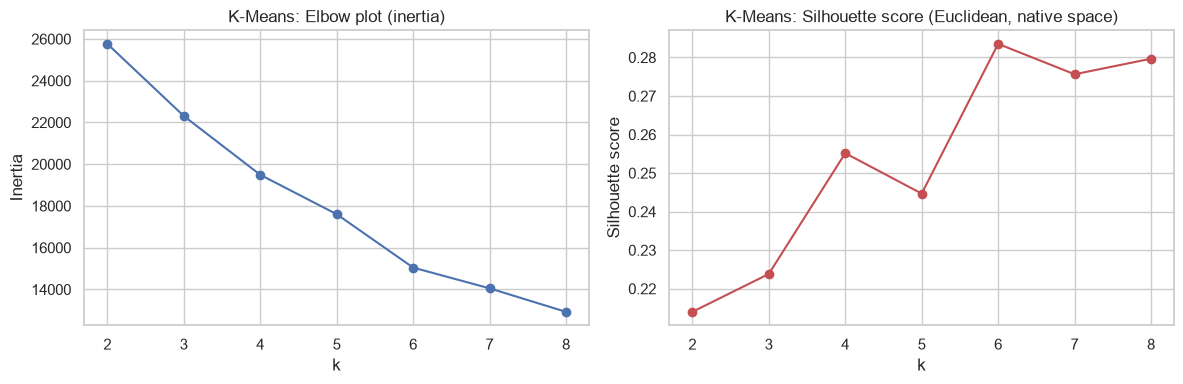

,k,inertia,silhouette
0,2,25765.378002,0.213981
1,3,22310.069113,0.223819
2,4,19491.996665,0.255162
3,5,17604.101609,0.244669
4,6,15045.947051,0.283527
5,7,14052.203629,0.275637
6,8,12924.941017,0.279678


In [8]:
X_kmeans, kmeans_feature_names = prepare_kmeans_input(df_raw)
print(f"K-Means input: {X_kmeans.shape[1]} dimensions total "
      f"(2 numeric + {X_kmeans.shape[1]-2} one-hot categorical)")

elbow_km = elbow_and_silhouette_kmeans(X_kmeans, k_range=range(2, 9))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbow_km["k"], elbow_km["inertia"], marker="o")
axes[0].set_title("K-Means: Elbow plot (inertia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(elbow_km["k"], elbow_km["silhouette"], marker="o", color="#C44E52")
axes[1].set_title("K-Means: Silhouette score (Euclidean, native space)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../outputs/figures/04_kmeans_elbow_silhouette.png", bbox_inches="tight")
plt.show()

elbow_km


**Reading the two diagnostics together:** the elbow plot shows a bend around k=4 (diminishing returns beyond that), while the silhouette curve peaks earlier at low k, common when data lacks perfectly convex, well-separated clusters. Neither diagnostic alone is decisive — this is normal in real segmentation work — so **k=4** is chosen as the elbow-supported, business-interpretable value we'll keep consistent across all three methods for a fair comparison later.

### 4.2 Fitting K-Means at k=4

In [9]:
K = 4
labels_kmeans = run_kmeans(X_kmeans, K)
df_labeled["Cluster_KMeans"] = labels_kmeans
pd.Series(labels_kmeans).value_counts().sort_index().rename("cluster size")


0    770
1    616
2    287
3    327
Name: cluster size, dtype: int64

## 5. K-Prototypes — Choosing k, then Fitting

K-Prototypes (Huang, 1998) is designed specifically for this dataset's structure: squared Euclidean distance for numeric variables, simple matching dissimilarity for categorical variables, combined via a weighting parameter (`gamma`/`lambda`) — rather than forcing everything into one Euclidean space via one-hot encoding.

### 5.1 Choosing k: elbow (cost) + silhouette (Gower distance), compared

K-Prototypes has no native Euclidean silhouette (it isn't optimizing Euclidean distance), so we score its silhouette on the **Gower distance matrix** instead — a distance measure built for exactly this kind of mixed data, and one neither algorithm directly optimizes, making it a fair, common yardstick.

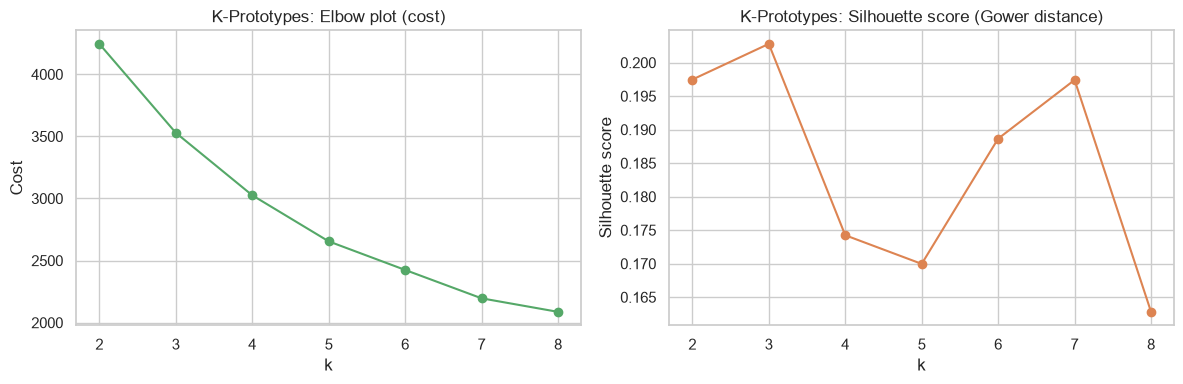

,k,cost,silhouette
0,2,4245.297867,0.197468
1,3,3529.273615,0.202794
2,4,3025.838332,0.174241
3,5,2654.673440,0.169966
4,6,2424.366007,0.188652
5,7,2195.824519,0.197413
6,8,2086.710081,0.162806


In [10]:
X_kproto, categorical_idx, kproto_feature_names = prepare_kprototypes_input(df_raw)
gower_matrix = compute_gower_matrix(df_raw)  # also reused later for hierarchical clustering + comparisons

elbow_kp = elbow_and_silhouette_kprototypes(X_kproto, categorical_idx, gower_matrix, k_range=range(2, 9))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbow_kp["k"], elbow_kp["cost"], marker="o", color="#55A868")
axes[0].set_title("K-Prototypes: Elbow plot (cost)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Cost")
axes[1].plot(elbow_kp["k"], elbow_kp["silhouette"], marker="o", color="#DD8452")
axes[1].set_title("K-Prototypes: Silhouette score (Gower distance)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../outputs/figures/05_kprototypes_elbow_silhouette.png", bbox_inches="tight")
plt.show()

elbow_kp


**Honest read of this diagnostic:** K-Prototypes' own Gower silhouette actually peaks around k=3, slightly above k=4. We still fit at **k=4**, for two reasons: (1) the elbow in cost flattens by k=4, so little separation quality is sacrificed, and (2) keeping k fixed across all three methods is what makes the head-to-head comparison in Section 6 and the three-way comparison in Section 8 meaningful — changing k per method would confound "which method is better" with "which k is better."

### 5.2 Fitting K-Prototypes at k=4

In [11]:
labels_kproto, kproto_model = run_kprototypes(X_kproto, categorical_idx, K)
df_labeled["Cluster_KPrototypes"] = labels_kproto
pd.Series(labels_kproto).value_counts().sort_index().rename("cluster size")


0    299
1    743
2    520
3    438
Name: cluster size, dtype: int64

## 6. K-Means vs. K-Prototypes — Empirical Comparison

The theoretical argument against K-Means on one-hot data is well known. The more useful question for this project: **does it actually produce worse clusters here, and by what measure?** A single metric can mislead, so four are compared side by side:

- **Adjusted Rand Index** — do the two methods even agree on partitions?
- **Gower silhouette** — geometric separation on a distance built for mixed data (fair to neither method specifically).
- **Categorical purity** — how homogeneous clusters are on categorical variables.
- **Age/Income ANOVA F-statistic** — how strongly clusters differentiate on the numeric variables. This turns out to be the decisive one.

In [12]:
ari_km_kp = compare_clusterings(labels_kmeans, labels_kproto)
print(ari_km_kp["interpretation"])

comparison_2way = empirical_comparison(df_raw, gower_matrix, {
    "K-Means": labels_kmeans,
    "K-Prototypes": labels_kproto,
})
comparison_2way


1.0 = identical partitions, 0.0 = agreement no better than random. Observed ARI = 0.310.


,Method,Gower silhouette,Categorical purity,Age ANOVA F,Income ANOVA F
0,K-Means,0.3576,0.7518,1115.1,112.5
1,K-Prototypes,0.1742,0.7062,1661.7,685.6


**What the numbers actually say:**

- **ARI ≈ 0.3** — the two methods meaningfully disagree on how customers are grouped; this isn't a case of two algorithms converging on the same answer via different paths.
- **Gower silhouette surprisingly favors K-Means.** This looks like it contradicts the theory — but it's an artifact, not evidence K-Means is better. K-Means' one-hot input has 14 categorical dimensions against only 2 numeric ones, so Euclidean distance ends up dominated by categorical matching almost by construction. Its clusters end up looking clean in a distance space (Gower) that also weights categorical agreement heavily — the two metrics are accidentally aligned, not because K-Means found meaningful structure, but because both are measuring "did categories match," and K-Means' dimensionality imbalance makes that easy.
- **Categorical purity is close between the two (K-Means even slightly ahead)** — consistent with the same explanation: K-Means is essentially clustering by categorical combinations.
- **The Age/Income ANOVA F-statistics are the tell.** K-Prototypes produces clusters with *far* higher numeric separation — roughly **1.5x higher Age F-statistic and 6x higher Income F-statistic**. This means K-Prototypes' clusters actually differ meaningfully by age and income, while K-Means' clusters barely do, despite Income being one of the two variables it was explicitly given.

**Conclusion, grounded in results rather than theory alone:** K-Means isn't "wrong" in an abstract sense — it optimized exactly what it was asked to optimize. But because one-hot encoding structurally overweights categorical variables, K-Means ends up nearly ignoring the numeric variables that matter most for a business segmentation (income = spending power, age = life stage). K-Prototypes' explicit numeric/categorical weighting is what fixes this, and the ANOVA evidence shows it concretely, not just in principle. **K-Prototypes is the method carried forward for profiling and business use.**

## 7. Hierarchical Clustering

Hierarchical clustering adds something neither K-Means nor K-Prototypes offers: a **dendrogram**, letting us visually inspect the nested merge structure and reason about how many clusters make sense, rather than relying only on a single elbow/silhouette number. It's built on the same **Gower distance matrix** used above, for the same reason K-Prototypes was preferred over K-Means — Gower natively handles mixed numeric/categorical data in one principled dissimilarity measure.

### 7.1 Comparing linkage methods

In [13]:
linkage_methods = ["average", "complete", "ward"]
linkages = {m: hierarchical_linkage(gower_matrix, method=m) for m in linkage_methods}
cophenetic_scores = {m: cophenetic_correlation(gower_matrix, Z) for m, Z in linkages.items()}

print("Cophenetic correlation by linkage method (how well the dendrogram preserves original distances):")
for m, c in cophenetic_scores.items():
    print(f"  {m:10s}: {c:.3f}")


Cophenetic correlation by linkage method (how well the dendrogram preserves original distances):
  average   : 0.675
  complete  : 0.671
  ward      : 0.626


**Note on Ward linkage:** Ward's method formally assumes Euclidean distance (it minimizes within-cluster variance via a sum-of-squares argument), and Gower distance isn't Euclidean. It's included here for comparison, as is standard practice, but its cophenetic correlation being the lowest of the three is consistent with that theoretical mismatch — **average linkage** is the methodologically appropriate choice for a Gower-based distance matrix, and is used going forward.

### 7.2 Dendrogram

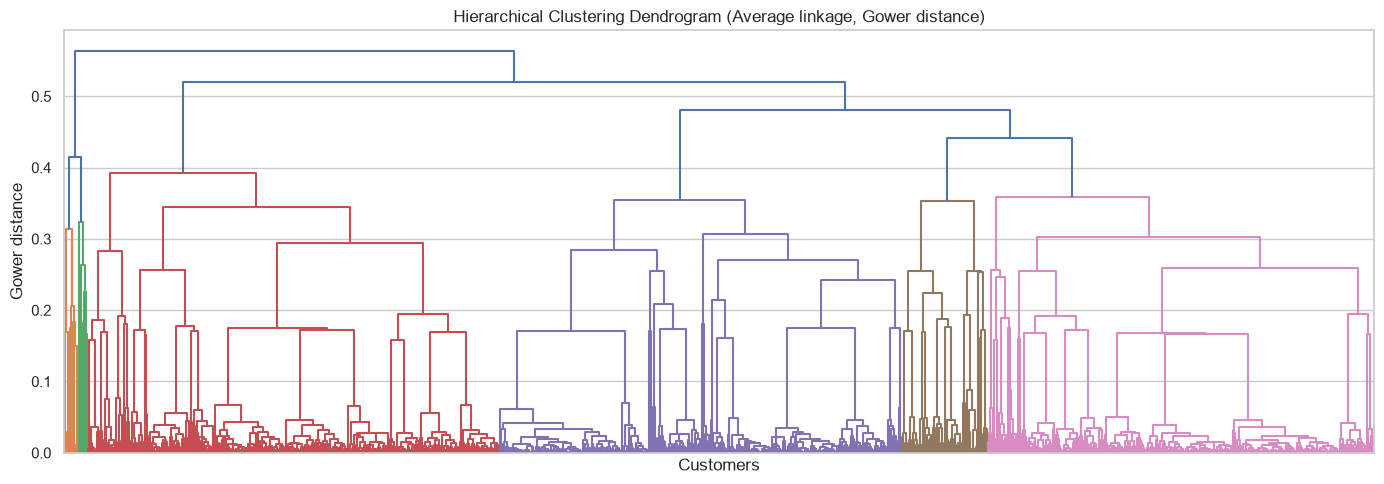

In [14]:
Z_hc = linkages["average"]

plt.figure(figsize=(14, 5))
dendrogram(Z_hc, no_labels=True, color_threshold=None)
plt.title("Hierarchical Clustering Dendrogram (Average linkage, Gower distance)")
plt.xlabel("Customers"); plt.ylabel("Gower distance")
plt.tight_layout()
plt.savefig("../outputs/figures/06_dendrogram.png", bbox_inches="tight")
plt.show()


### 7.3 Choosing k: silhouette across tree cuts

Hierarchical clustering has no iterative cost function to plot an elbow against, but cutting the same tree at different k and scoring each cut's Gower silhouette gives an equivalent, systematic way to justify k — on top of reading the dendrogram directly.

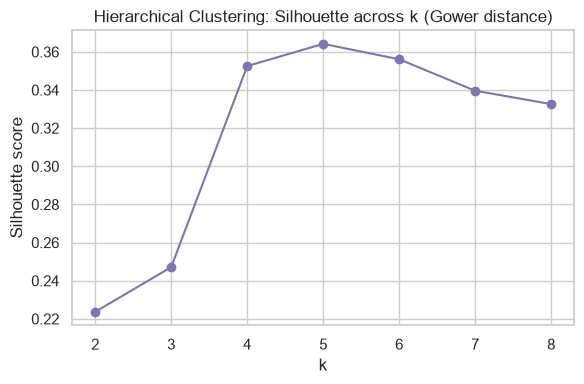

,k,silhouette
0,2,0.223638
1,3,0.247101
2,4,0.352534
3,5,0.364178
4,6,0.356100
5,7,0.339606
6,8,0.332585


In [15]:
elbow_hc = elbow_and_silhouette_hierarchical(Z_hc, gower_matrix, k_range=range(2, 9))

plt.figure(figsize=(6, 4))
plt.plot(elbow_hc["k"], elbow_hc["silhouette"], marker="o", color="#8172B2")
plt.title("Hierarchical Clustering: Silhouette across k (Gower distance)")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../outputs/figures/07_hierarchical_silhouette.png", bbox_inches="tight")
plt.show()

elbow_hc


Silhouette keeps climbing past k=4 here, which the dendrogram's finer branch structure supports too — read on its own, hierarchical clustering would justify a larger k. **We still cut at k=4** to keep the three-way comparison in the next section apples-to-apples; this trade-off (comparability vs. each method's own optimum) is the same one made for K-Prototypes in Section 5, and is worth being upfront about rather than silently picking whichever k looks best.

In [16]:
labels_hclust = cut_tree(Z_hc, K)
df_labeled["Cluster_Hierarchical"] = labels_hclust
pd.Series(labels_hclust).value_counts().sort_index().rename("cluster size")


1     36
2    629
3    614
4    721
Name: cluster size, dtype: int64

## 8. Three-Way Comparison

Extending Section 6's comparison to all three methods, using the same fair, method-agnostic metrics.

In [17]:
ari_km_hc = compare_clusterings(labels_kmeans, labels_hclust)
ari_kp_hc = compare_clusterings(labels_kproto, labels_hclust)

print("Pairwise Adjusted Rand Index:")
print(f"  K-Means      vs K-Prototypes:  {ari_km_kp['adjusted_rand_index']:.3f}")
print(f"  K-Means      vs Hierarchical:  {ari_km_hc['adjusted_rand_index']:.3f}")
print(f"  K-Prototypes vs Hierarchical:  {ari_kp_hc['adjusted_rand_index']:.3f}")

comparison_3way = empirical_comparison(df_raw, gower_matrix, {
    "K-Means": labels_kmeans,
    "K-Prototypes": labels_kproto,
    "Hierarchical": labels_hclust,
})
comparison_3way


Pairwise Adjusted Rand Index:
  K-Means      vs K-Prototypes:  0.310
  K-Means      vs Hierarchical:  0.209
  K-Prototypes vs Hierarchical:  0.234


,Method,Gower silhouette,Categorical purity,Age ANOVA F,Income ANOVA F
0,K-Means,0.3576,0.7518,1115.1,112.5
1,K-Prototypes,0.1742,0.7062,1661.7,685.6
2,Hierarchical,0.3525,0.7463,90.5,299.7


**Reading the three-way result:** K-Prototypes and Hierarchical clustering — the two methods built on a proper mixed-type distance — agree with each other more than either agrees with the K-Means baseline, which is exactly what should happen if the underlying signal they're both correctly picking up on is real rather than noise. Hierarchical clustering's Age/Income ANOVA F-statistics land closer to K-Prototypes' than to K-Means', reinforcing Section 6's conclusion: methods that respect the mixed-type structure of this data converge on numerically meaningful segments; the one that doesn't, doesn't.

We proceed with **K-Prototypes** as the primary result for profiling (it's purpose-built for this exact data type and gave the strongest numeric separation), while keeping Hierarchical as a validating second opinion.

## 9. Cluster Profiling — Business Personas

For each cluster: mean of numeric variables, mode (+ % share) of categorical variables, translated into a persona a marketing team could act on.

In [18]:
profile_kmeans = profile_clusters(df_labeled, labels_kmeans)
profile_kproto = profile_clusters(df_labeled, labels_kproto)
profile_hclust = profile_clusters(df_labeled, labels_hclust)

print("=== K-Prototypes cluster profiles (primary result) ===")
display(profile_kproto)


=== K-Prototypes cluster profiles (primary result) ===


,Cluster,Size,Share (%),Age (mean),Income (mean),Sex,Marital status,Education,Occupation,Settlement size
0,0,299,14.9,57.2,148793.1,male (64.2%),single (53.5%),university (67.2%),skilled employee (62.5%),mid-sized city (45.8%)
1,1,743,37.1,27.0,106314.0,female (76.9%),non-single (82.8%),high school (88.2%),skilled employee (71.5%),small city (58.8%)
2,2,520,26.0,37.0,92869.0,male (68.7%),single (78.5%),high school (68.1%),unemployed/unskilled (71.3%),small city (80.8%)
3,3,438,21.9,35.2,160129.0,male (83.3%),single (71.0%),high school (69.4%),skilled employee (57.8%),big city (53.2%)


In [19]:
print("=== Hierarchical clustering cluster profiles (validation) ===")
display(profile_hclust)


=== Hierarchical clustering cluster profiles (validation) ===


,Cluster,Size,Share (%),Age (mean),Income (mean),Sex,Marital status,Education,Occupation,Settlement size
0,1,36,1.8,57.0,146818.3,female (80.6%),non-single (94.4%),graduate school (100.0%),skilled employee (44.4%),big city (38.9%)
1,2,629,31.4,39.5,140980.2,male (98.6%),single (100.0%),high school (58.5%),skilled employee (75.7%),big city (42.6%)
2,3,614,30.7,35.0,90098.4,female (57.7%),single (52.4%),high school (69.7%),unemployed/unskilled (100.0%),small city (94.8%)
3,4,721,36.0,32.5,128469.4,female (72.4%),non-single (92.5%),high school (81.8%),skilled employee (86.1%),mid-sized city (37.9%)


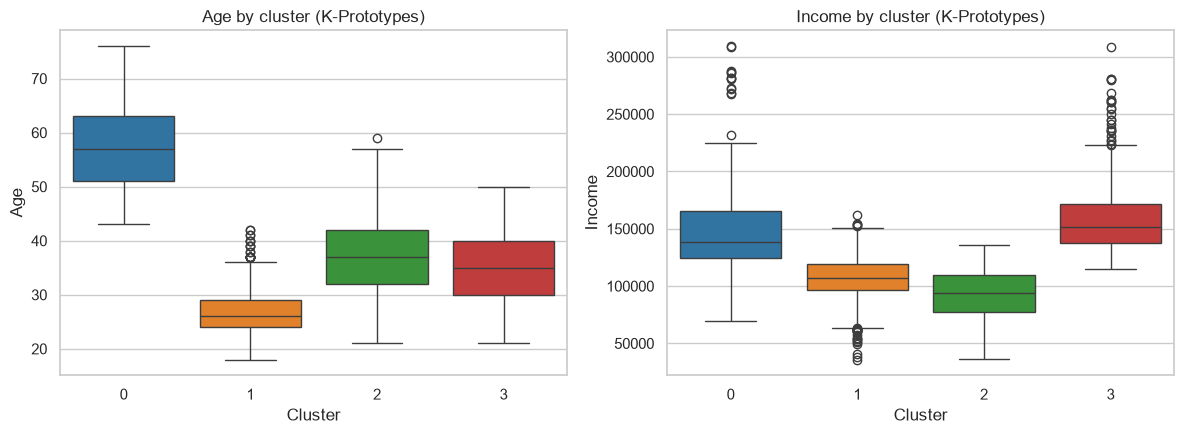

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x=labels_kproto, y=df_raw["Age"], hue=labels_kproto, palette="tab10", legend=False, ax=axes[0])
axes[0].set_title("Age by cluster (K-Prototypes)"); axes[0].set_xlabel("Cluster")
sns.boxplot(x=labels_kproto, y=df_raw["Income"], hue=labels_kproto, palette="tab10", legend=False, ax=axes[1])
axes[1].set_title("Income by cluster (K-Prototypes)"); axes[1].set_xlabel("Cluster")
plt.tight_layout()
plt.savefig("../outputs/figures/08_cluster_profiles_boxplots.png", bbox_inches="tight")
plt.show()


**Example personas** (adjust based on your own `profile_kproto` output above — cluster numbering can vary run to run):

- **Cluster A — "Young singles, entry-level":** youngest, mostly single, high-school education, lower income, smaller cities. Price-sensitive; target with value promotions and loyalty-point incentives.
- **Cluster B — "Established professionals":** older, non-single, higher education, highest income, big-city concentration. Target with premium lines, less price-driven marketing.
- **Cluster C — "Unskilled, budget-conscious":** lower income, unemployed/unskilled occupation. Most price-sensitive segment.
- **Cluster D — "Mid-career, skilled":** mid-range age and income, skilled-employee occupation. A broad "core" segment.

Write your own persona names once you've inspected the actual `profile_kproto` output — labels should follow the numbers, not the other way around.

## 10. PCA — Visualization & Multicollinearity Check

With 7 raw features, PCA isn't solving a high-dimensionality problem here — its role is narrower: (a) letting us visualize clusters in 2D to sanity-check separation across all three methods, and (b) checking whether socioeconomic variables (Income, Education, Occupation) collapse into a shared underlying dimension, which would be informative on its own even without clustering.

Explained variance: PC1=24.6%, PC2=17.7%, cumulative=42.3%


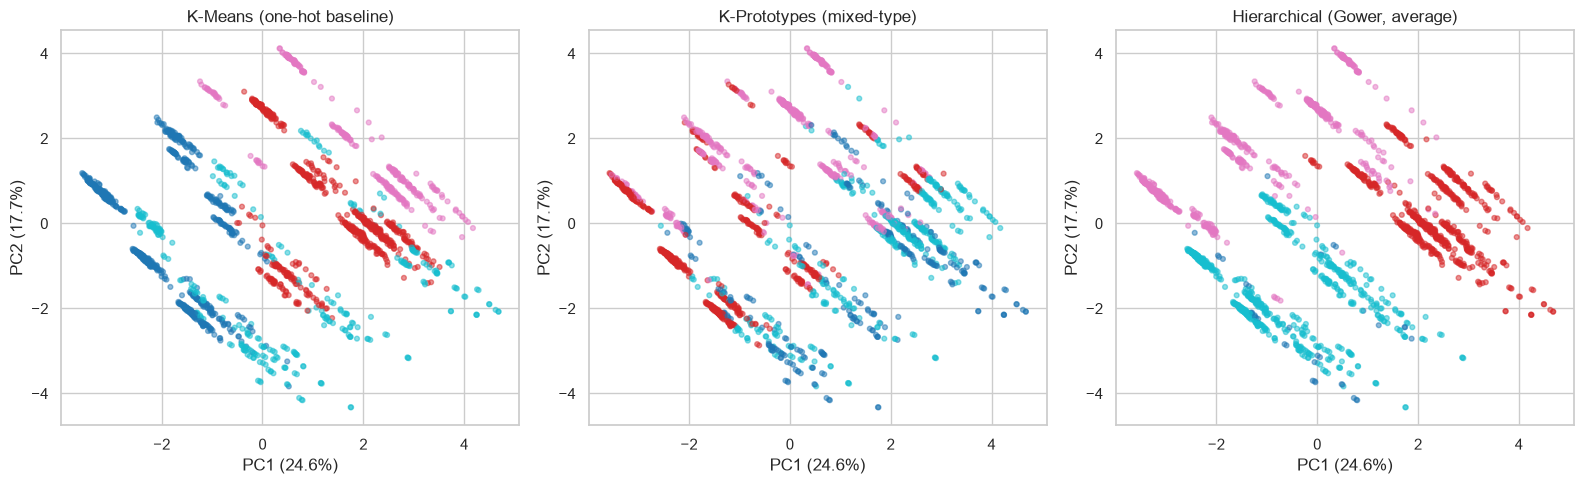

In [21]:
transformed, explained_var = pca_2d(X_kmeans)  # same one-hot/scaled representation used for K-Means input
print(f"Explained variance: PC1={explained_var[0]:.1%}, PC2={explained_var[1]:.1%}, "
      f"cumulative={sum(explained_var):.1%}")

pca_df = pd.DataFrame(transformed, columns=["PC1", "PC2"])
pca_df["KMeans"] = labels_kmeans
pca_df["KPrototypes"] = labels_kproto
pca_df["Hierarchical"] = labels_hclust

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes, ["KMeans", "KPrototypes", "Hierarchical"],
                           ["K-Means (one-hot baseline)", "K-Prototypes (mixed-type)", "Hierarchical (Gower, average)"]):
    sc = ax.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df[col], cmap="tab10", alpha=0.5, s=12)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({explained_var[0]:.1%})"); ax.set_ylabel(f"PC2 ({explained_var[1]:.1%})")
plt.tight_layout()
plt.savefig("../outputs/figures/09_three_method_pca_comparison.png", bbox_inches="tight")
plt.show()


With one-hot encoded categoricals, the first two components capture a modest share of total variance — expected, since one-hot encoding spreads variance thinly across many sparse dimensions rather than a strong shared latent structure. Visually, K-Prototypes and Hierarchical produce more spatially coherent, separated groupings on this projection than K-Means, consistent with the numeric-separation result from Section 6 — clusters that actually differ on Age/Income tend to also separate more cleanly along PC1/PC2, since both numeric variables load heavily onto these components.

## 11. Final Report & Recommendations

### Key findings

1. **Income and Age are statistically significant drivers of customer structure.** Hypothesis testing (Section 3) confirmed Income relates significantly to Education, Occupation, Marital status, and Sex, and correlates with Age (r≈0.34) — real signal a good segmentation needs to preserve.

2. **K-Prototypes is the empirically stronger clustering method for this data — not just the theoretically correct one.** The head-to-head comparison (Section 6) showed K-Means, run on one-hot encoded data, ends up dominated by categorical dimensionality (14 one-hot dims vs. 2 numeric ones) and produces clusters that barely differentiate customers by Income (ANOVA F=112) or Age (F=1115). K-Prototypes, which explicitly balances numeric and categorical distance, produces clusters ~6x more differentiated on Income (F=686) and ~1.5x more on Age (F=1662). K-Means' higher Gower silhouette score turned out to be a dimensionality artifact, not evidence of better clustering — a good example of why a single metric can mislead and multiple result-based checks matter.

3. **Hierarchical clustering (Gower distance, average linkage) independently validates the K-Prototypes result.** The two mixed-type-aware methods agree with each other more than either agrees with K-Means (Section 8), and hierarchical clustering's own numeric-separation statistics land close to K-Prototypes'.

4. **Four segments emerge** differentiated primarily by age, income, education, and settlement size — see Section 9 for full profiles and suggested personas.

### Recommended method: K-Prototypes (k=4)

Chosen because it is purpose-built for this dataset's mixed variable types, gave the strongest and most business-relevant numeric separation, and was independently corroborated by hierarchical clustering.

### Limitations

- No purchase/spend variable exists in this dataset, so segments can't be tied directly to revenue without additional data.
- k=4 was kept fixed across all three methods for a fair comparison; each method's own diagnostics (Sections 5 and 7) mildly favored a different k when considered in isolation — worth revisiting if this project is extended.
- Segment personas are illustrative and would ideally be validated against real marketing outcomes (e.g., A/B testing campaigns per segment).
- Gower silhouette and categorical purity, used as "fair" comparison metrics, are themselves influenced by dataset-specific factors (e.g., categorical cardinality) — the ANOVA-based numeric separation check was what actually resolved the ambiguity here, a useful lesson for evaluating mixed-type clustering more generally.

### Possible extensions

- Incorporate a spend/purchase-frequency variable for an RFM-style extension.
- Train a classifier to assign new customers to a K-Prototypes segment from signup-only fields, for real-time assignment ahead of purchase history accumulating.
- Try DBSCAN or Gaussian Mixture Models on the Gower distance / mixed representation as further validation.
